In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, Dropout, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import glob,random

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print(os.listdir("/content/drive/MyDrive/Garbage classification/archive/Garbage classification/Garbage classification"))

['metal', 'glass', 'cardboard', 'paper', 'trash', 'plastic']


['/content/drive/MyDrive/Garbage classification/archive/Garbage classification/Garbage classification/metal/metal249.jpg', '/content/drive/MyDrive/Garbage classification/archive/Garbage classification/Garbage classification/metal/metal171.jpg', '/content/drive/MyDrive/Garbage classification/archive/Garbage classification/Garbage classification/metal/metal184.jpg', '/content/drive/MyDrive/Garbage classification/archive/Garbage classification/Garbage classification/metal/metal253.jpg', '/content/drive/MyDrive/Garbage classification/archive/Garbage classification/Garbage classification/metal/metal17.jpg', '/content/drive/MyDrive/Garbage classification/archive/Garbage classification/Garbage classification/metal/metal100.jpg', '/content/drive/MyDrive/Garbage classification/archive/Garbage classification/Garbage classification/metal/metal233.jpg', '/content/drive/MyDrive/Garbage classification/archive/Garbage classification/Garbage classification/metal/metal247.jpg', '/content/drive/MyDrive/

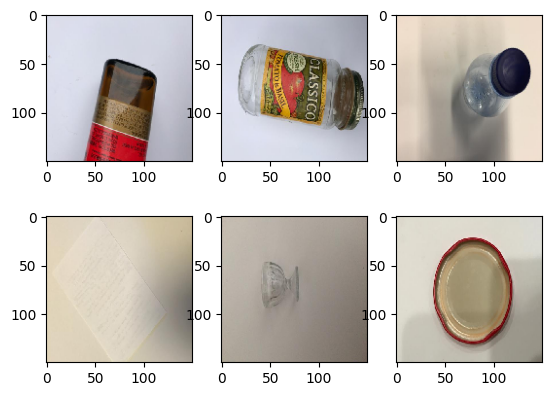

In [ ]:
from keras.preprocessing import image
base_path = "/content/drive/MyDrive/Garbage classification/archive/Garbage classification/Garbage classification"
img_list = glob.glob(os.path.join(base_path, '*/*.jpg'))
print(img_list)
for i, img_path in enumerate(random.sample(img_list, 6)):
    img = image.load_img(img_path, target_size=(150, 150))
    img = image.img_to_array(img, dtype=np.uint8)
    plt.subplot(2, 3, i+1)
    plt.imshow(img.squeeze())

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.1,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    validation_split=0.1,
    rotation_range=45
)

test_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.1
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    base_path,
    target_size=(150, 150),
    batch_size=16,
    class_mode='categorical',
    subset='training',
    seed=0
)

test_generator = test_datagen.flow_from_directory(
    base_path,
    target_size=(150, 150),
    batch_size=16,
    class_mode='categorical',
    subset='validation',
    seed=0
)

Found 2285 images belonging to 6 classes.
Found 252 images belonging to 6 classes.


In [ ]:
print (train_generator.class_indices)

{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [ ]:
labels = '\n'.join(sorted(train_generator.class_indices.keys()))

with open("/content/drive/MyDrive/Garbage classification/labels.txt", 'w') as f:
  f.write(labels)

In [ ]:
path = "/content/drive/MyDrive/Garbage classification/labels.txt"
label = np.array(open(path).read().splitlines())
print(label)

['cardboard' 'glass' 'metal' 'paper' 'plastic' 'trash']


In [ ]:

from tensorflow.keras.optimizers import Adam

model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu',input_shape=(150, 150, 3)))
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.25))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.25))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(6, activation='softmax'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │       2,367,552 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 6)                   │             390 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,461,190 (9.39 MB)

 Trainable params: 2,461,190 (9.39 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss='categorical_crossentropy', optimizer="adam", metrics=['accuracy'])

In [ ]:
batch_size = 32
epochs = 10
steps_per_epoch = train_generator.n // batch_size
validation_steps = test_generator.n // batch_size

history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=epochs,
    validation_data=test_generator,
    validation_steps=validation_steps
)

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


71/71 ━━━━━━━━━━━━━━━━━━━━ 210s 3s/step - accuracy: 0.2105 - loss: 2.0571 - val_accuracy: 0.2500 - val_loss: 1.7072
Epoch 2/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.2487 - loss: 1.6680 - val_accuracy: 0.2411 - val_loss: 1.6503
Epoch 3/10
 1/71 ━━━━━━━━━━━━━━━━━━━━ 1:02 886ms/step - accuracy: 0.1250 - loss: 1.7822

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


71/71 ━━━━━━━━━━━━━━━━━━━━ 23s 312ms/step - accuracy: 0.1250 - loss: 1.7822 - val_accuracy: 0.2500 - val_loss: 1.6111
Epoch 4/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.3250 - loss: 1.5714 - val_accuracy: 0.3571 - val_loss: 1.5425
Epoch 5/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.3654 - loss: 1.4726 - val_accuracy: 0.3482 - val_loss: 1.5753
Epoch 6/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5625 - loss: 1.2710 - val_accuracy: 0.3214 - val_loss: 1.6432
Epoch 7/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.4110 - loss: 1.4401 - val_accuracy: 0.3214 - val_loss: 1.4737
Epoch 8/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.5074 - loss: 1.2842 - val_accuracy: 0.4643 - val_loss: 1.2400
Epoch 9/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2500 - loss: 1.6096 - val_accuracy: 0.5357 - val_loss: 1.3886
Epoch 10/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.4410 - loss: 1.3396 - val_accuracy: 0.5089 - val_loss: 1.330

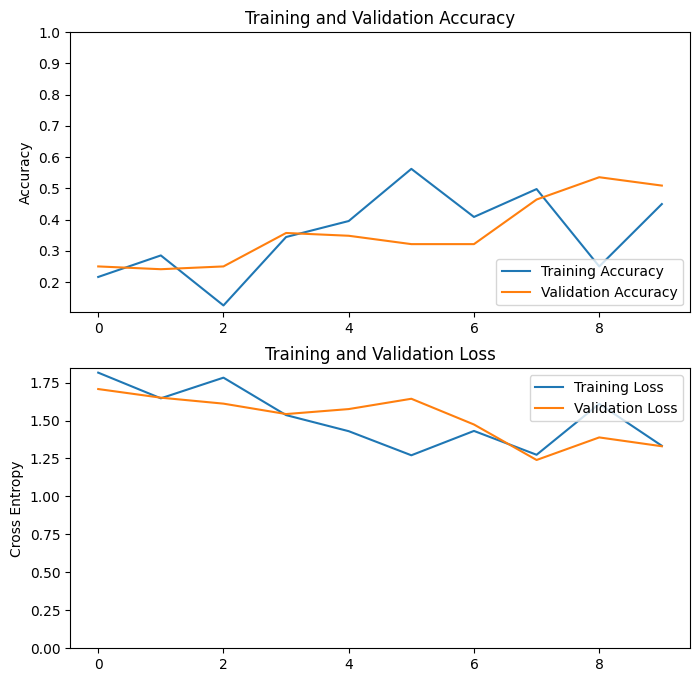

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,max(plt.ylim())])
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
IMG_SHAPE = (150, 150, 3)
base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,
                                               include_top=False,
                                               weights='imagenet')

<ipython-input-32-e754d801b357>:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
base_model.trainable = False

In [ ]:
model_transfer = tf.keras.Sequential([
  base_model,
  tf.keras.layers.Conv2D(128, 3, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.GlobalAveragePooling2D(),
  tf.keras.layers.Dense(6, activation='softmax')
])

In [ ]:
model_transfer.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
batch_size = 32
epochs = 10
steps_per_epoch = train_generator.n / batch_size
validation_steps =test_generator.n / batch_size

history = model_transfer.fit(
    train_generator,
    epochs=epochs,
    validation_data=test_generator
)

Epoch 1/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 83s 532ms/step - accuracy: 0.5396 - loss: 1.3652 - val_accuracy: 0.7262 - val_loss: 0.7005
Epoch 2/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 75s 517ms/step - accuracy: 0.7432 - loss: 0.6937 - val_accuracy: 0.8095 - val_loss: 0.5375
Epoch 3/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 89s 564ms/step - accuracy: 0.7886 - loss: 0.6068 - val_accuracy: 0.7778 - val_loss: 0.5338
Epoch 4/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 137s 529ms/step - accuracy: 0.8253 - loss: 0.4999 - val_accuracy: 0.7262 - val_loss: 0.6778
Epoch 5/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 82s 547ms/step - accuracy: 0.8276 - loss: 0.4758 - val_accuracy: 0.8413 - val_loss: 0.4310
Epoch 6/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 75s 517ms/step - accuracy: 0.8457 - loss: 0.4398 - val_accuracy: 0.8294 - val_loss: 0.4917
Epoch 7/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 79s 540ms/step - accuracy: 0.8477 - loss: 0.4080 - val_accuracy: 0.8135 - val_loss: 0.5133
Epoch 8/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 75s 517ms/step - accuracy: 0.8577 - loss: 

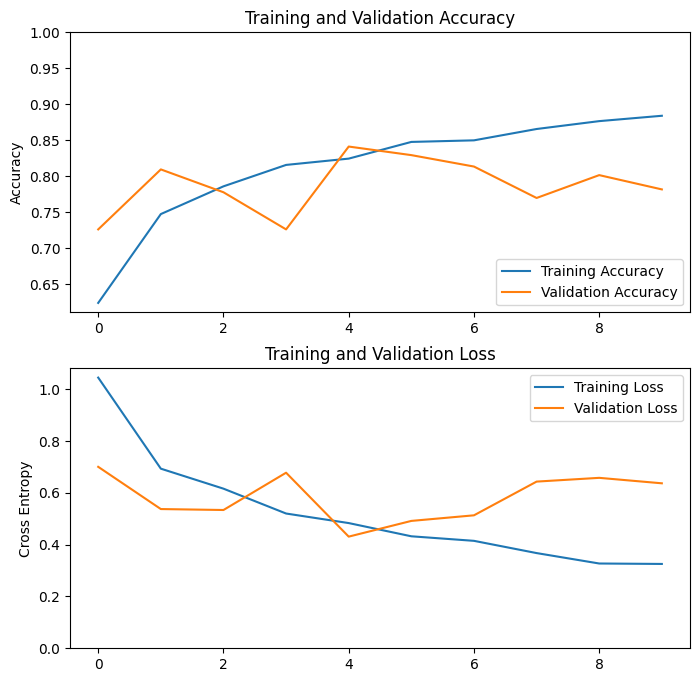

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,max(plt.ylim())])
plt.title('Training and Validation Loss')
plt.show()